In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
X = df.drop("Churn",axis=1)
y = df["Churn"]

In [5]:
X.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [6]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str

In [7]:
X.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
dtype: object

In [8]:
X = X.drop("customerID", axis=1)

In [9]:
X.shape

(7043, 19)

In [10]:
df[df["TotalCharges"].str.strip() == ""][[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [12]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [13]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [14]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [15]:
X = df.drop("Churn", axis=1)
X = X.drop("customerID", axis=1)

In [16]:
X.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [17]:
categorical_features = df.select_dtypes(
    include=["object","str"]
).columns.to_list()
categorical_features

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [18]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [19]:
categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical:")
print(categorical_features)

print("\nNumerical:")
print(numerical_features)

Categorical:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [20]:
for column in categorical_features:
    print(f"\n{column}:")
    print(X[column].unique())


gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract:
<StringArray>
['Month-to-month', 

In [21]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [22]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [23]:
service_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

X["number_of_services"] = (
    X[service_features] == "Yes"
).sum(axis=1)

In [24]:
X["number_of_services"].value_counts().sort_index()

number_of_services
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

In [25]:
X["number_of_services"].describe()

count    7043.000000
mean        2.037910
std         1.847682
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: number_of_services, dtype: float64

In [26]:
pd.crosstab(
    X["number_of_services"],
    y,
    normalize="index"
) * 100

Churn,0,1
number_of_services,,
0,78.593961,21.406039
1,54.244306,45.755694
2,64.181994,35.818006
3,72.629696,27.370304
4,77.699531,22.300469
5,87.565674,12.434326
6,94.718310,5.281690


In [27]:
X["is_new_customer"] = (
    X["tenure"] <= 6
).astype(int)

In [28]:
pd.crosstab(
    X["is_new_customer"],
    y,
    normalize="index"
) * 100

Churn,0,1
is_new_customer,,
0,80.492629,19.507371
1,47.062795,52.937205


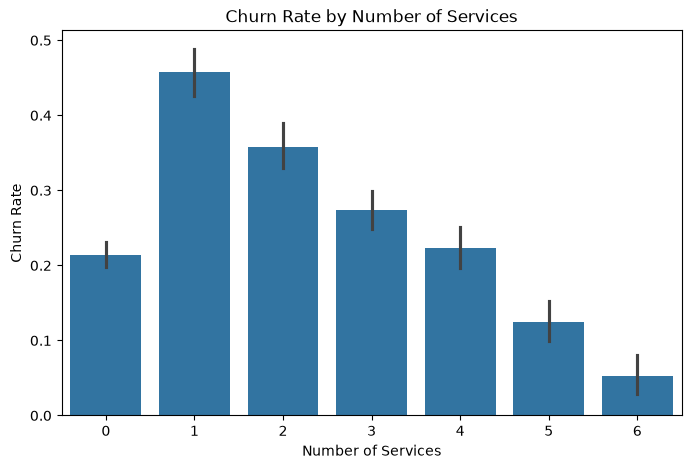

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))

sns.barplot(
    data=pd.DataFrame({
        "number_of_services": X["number_of_services"],
        "Churn": y
    }),
    x="number_of_services",
    y="Churn"
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate")
plt.show()

In [32]:
X["avg_monthly_spend"] = np.where(
    X["tenure"] > 0,
    X["TotalCharges"] / X["tenure"],
    X["MonthlyCharges"]
)

In [33]:
X["avg_monthly_spend"].describe()

count    7043.000000
mean       64.762906
std        30.189796
min        13.775000
25%        35.935156
50%        70.337500
75%        90.174158
max       121.400000
Name: avg_monthly_spend, dtype: float64

In [34]:
X[["MonthlyCharges", "avg_monthly_spend"]].head(10)

,MonthlyCharges,avg_monthly_spend
0,29.85,29.850000
1,56.95,55.573529
2,53.85,54.075000
3,42.30,40.905556
4,70.70,75.825000
5,99.65,102.562500
6,89.10,88.609091
7,29.75,30.190000
8,104.80,108.787500
9,56.15,56.257258


In [35]:
X["charge_difference"] = (
    X["MonthlyCharges"] - X["avg_monthly_spend"]
)

In [36]:
X["charge_difference"].describe()

count    7043.000000
mean       -0.001213
std         2.614121
min       -18.900000
25%        -1.159091
50%         0.000000
75%         1.145567
max        19.125000
Name: charge_difference, dtype: float64

In [37]:
pd.crosstab(
    pd.qcut(
        X["charge_difference"],
        q=5,
        duplicates="drop"
    ),
    y,
    normalize="index"
) * 100

Churn,0,1
charge_difference,,
"(-18.901, -1.523]",69.198013,30.801987
"(-1.523, -0.299]",83.664773,16.335227
"(-0.299, 0.285]",63.236338,36.763662
"(0.285, 1.535]",83.025568,16.974432
"(1.535, 19.125]",68.204400,31.795600


In [38]:
experimental_features = [
    "number_of_services",
    "is_new_customer",
    "avg_monthly_spend",
    "charge_difference"
]

X = X.drop(columns=experimental_features)

In [40]:
X.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']